# k-Nearest Neighbors Classification on Synthetic Blobs

## Project Overview

This notebook introduces instance-based classification using a controlled four-class dataset. The experiments show how the number of neighbors and distance weighting affect decision boundaries, training accuracy, test accuracy, and class-level errors.

### Technical Coverage

- Instance-based learning
- Euclidean-distance neighborhoods
- Uniform and distance-weighted voting
- Decision-boundary visualization
- Training vs. test performance
- Confusion-matrix analysis
- Sensitivity to the number of neighbors

## 1. k-Nearest Neighbors as an Instance-Based Model

k-nearest neighbors stores the training instances rather than estimating a global parametric model. For a new observation, the method identifies the \(k\) closest stored observations and combines their responses.

For classification, the standard formulation uses the most common class among the neighbors. A distance-weighted formulation gives closer neighbors greater influence on the final prediction.

### Basic k-NN Workflow

The instance-based prediction process used in the experiments is:

1. Store the training instances in the original feature space.
2. For each test observation, compute its distance to the stored training observations.
3. Identify the \(k\) nearest training instances.
4. For classification, predict the class receiving the strongest neighborhood vote.
5. For regression, predict from the neighboring target values.

This makes the prediction for a new observation depend directly on nearby stored examples rather than on a fitted global parametric equation.

### Distance-Weighted Neighborhoods

The weighted variant uses the same nearest-neighbor search while allowing closer observations to contribute more strongly to the prediction. The synthetic experiments below compare uniform and distance-weighted neighborhood behavior.

## 2. Synthetic Four-Class Dataset

In [1]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = make_blobs(n_samples = [50,50,50,50], centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,10], random_state=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

## 3. One-Neighbor Classification

With \(k=1\), each prediction is determined by the single closest training observation. The model therefore achieves perfect training accuracy, while the test result reflects local generalization.

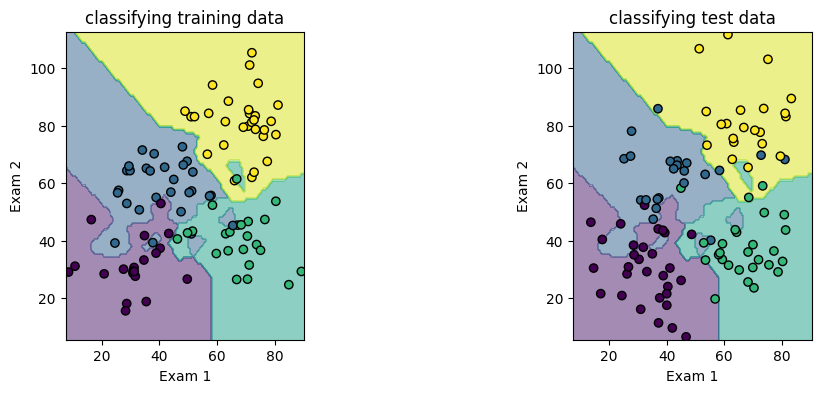

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.8400
Confusion matrix:
[[24  5  1  0]
 [ 0 18  0  4]
 [ 1  2 22  2]
 [ 0  0  1 20]]


In [2]:
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train, y_train)

fig, ax = plt.subplots(1,2,figsize=(12, 4))

disp = DecisionBoundaryDisplay.from_estimator(classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax[0].set_title('classifying training data')
ax[0].set_aspect('equal')

disp = DecisionBoundaryDisplay.from_estimator(      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
ax[1].set_title('classifying test data')
ax[1].set_aspect('equal')
plt.show()

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

## 4. Increasing the Neighborhood Size

Using three neighbors smooths the decision surface by allowing multiple nearby observations to influence each prediction.

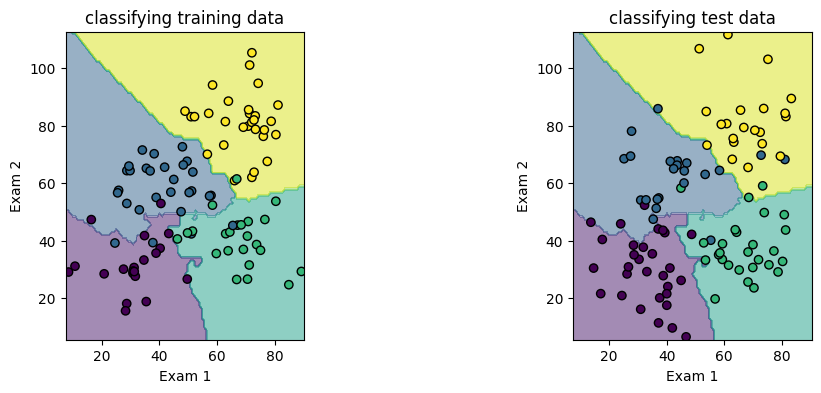

Prediction accuracy on training set: 0.9200
Prediction accuracy on test set:     0.8600
Confusion matrix:
[[27  2  1  0]
 [ 1 16  1  4]
 [ 1  1 23  2]
 [ 0  1  0 20]]


In [3]:
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X_train, y_train)

fig, ax = plt.subplots(1,2,figsize=(12, 4))

disp = DecisionBoundaryDisplay.from_estimator(classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax[0].set_title('classifying training data')
ax[0].set_aspect('equal')

disp = DecisionBoundaryDisplay.from_estimator(      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
ax[1].set_title('classifying test data')
ax[1].set_aspect('equal')
plt.show()

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

## 5. Distance-Weighted Voting

Distance weighting gives closer observations more influence than farther neighbors. The following experiments compare several weighted neighborhood sizes.

### Weighted k-NN with k = 2

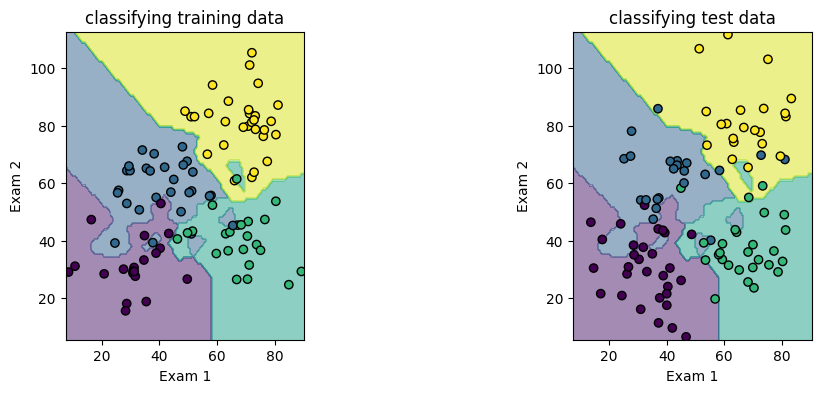

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.8400
Confusion matrix:
[[24  5  1  0]
 [ 0 18  0  4]
 [ 1  2 22  2]
 [ 0  0  1 20]]


In [4]:
classifier = KNeighborsClassifier(n_neighbors=2,weights='distance')
classifier.fit(X_train, y_train)

fig, ax = plt.subplots(1,2,figsize=(12, 4))

disp = DecisionBoundaryDisplay.from_estimator(classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax[0].set_title('classifying training data')
ax[0].set_aspect('equal')

disp = DecisionBoundaryDisplay.from_estimator(      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
ax[1].set_title('classifying test data')
ax[1].set_aspect('equal')
plt.show()

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

### Weighted k-NN with k = 5

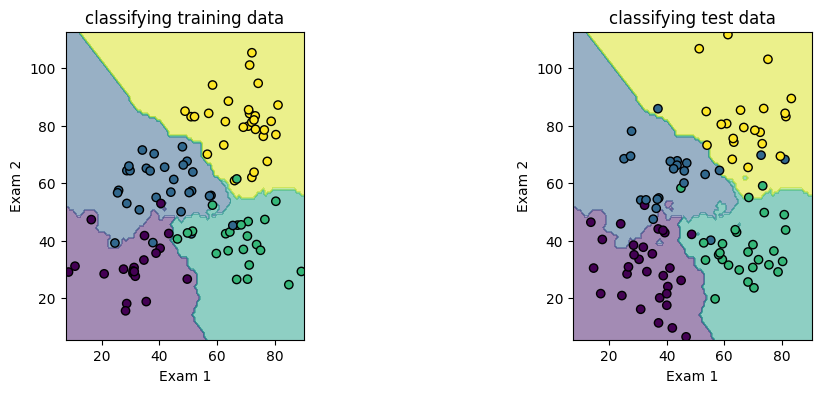

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.9000
Confusion matrix:
[[27  2  1  0]
 [ 0 18  1  3]
 [ 0  1 25  1]
 [ 0  1  0 20]]


In [5]:
classifier = KNeighborsClassifier(n_neighbors=5,weights='distance')
classifier.fit(X_train, y_train)

fig, ax = plt.subplots(1,2,figsize=(12, 4))

disp = DecisionBoundaryDisplay.from_estimator(classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax[0].set_title('classifying training data')
ax[0].set_aspect('equal')

disp = DecisionBoundaryDisplay.from_estimator(      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
ax[1].set_title('classifying test data')
ax[1].set_aspect('equal')
plt.show()

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

### Weighted k-NN with k = 8

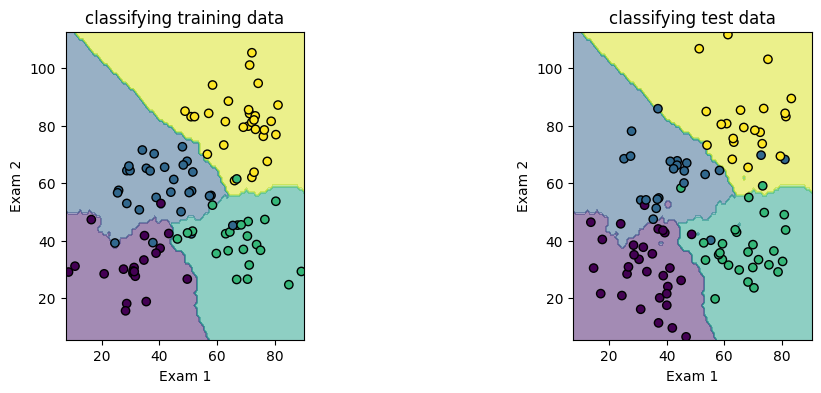

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.9100
Confusion matrix:
[[27  2  1  0]
 [ 0 18  1  3]
 [ 0  1 25  1]
 [ 0  0  0 21]]


In [6]:
classifier = KNeighborsClassifier(n_neighbors=8,weights='distance')
classifier.fit(X_train, y_train)

fig, ax = plt.subplots(1,2,figsize=(12, 4))

disp = DecisionBoundaryDisplay.from_estimator(classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[0],alpha=0.5)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k")
ax[0].set_title('classifying training data')
ax[0].set_aspect('equal')

disp = DecisionBoundaryDisplay.from_estimator(      classifier, X, response_method="predict",
      xlabel="Exam 1", ylabel="Exam 2",ax=ax[1],alpha=0.5)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k")
ax[1].set_title('classifying test data')
ax[1].set_aspect('equal')
plt.show()

pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

## 6. Small-Sample Prediction Check

A second synthetic split provides a compact example in which the test observations can be inspected directly before verifying the one-neighbor predictions with scikit-learn.

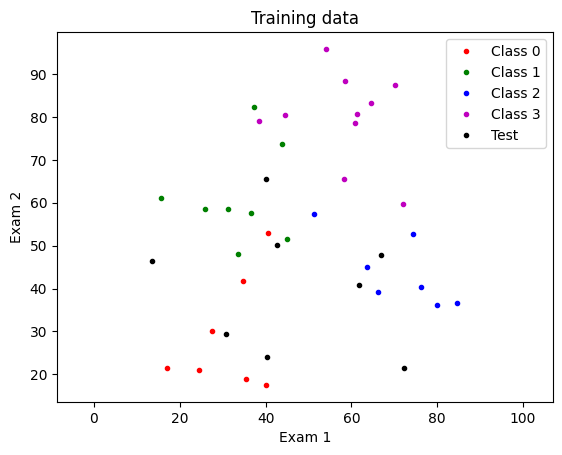

In [7]:
X, y = make_blobs(n_samples = [10,10,10,10], centers = [[35,30],[40,60],[70,40],[65,80]],cluster_std = [10,10,10,10], random_state=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


colors = 'rgbm'
classes = sorted(set(y))
plt.figure()
for c in classes:
  ind = (y_train==c)
  plt.plot(X_train[ind,0],X_train[ind,1],'.'+colors[c],label = 'Class '+str(c))
plt.plot(X_test[:,0],X_test[:,1],'.k',label = 'Test')
plt.xlabel("Exam 1")
plt.ylabel("Exam 2")
plt.legend()
plt.title('Training data')
plt.axis('equal')
plt.show()

### Test Observations

In [8]:
print(X_test)

[[40.00009761 65.42352572]
 [13.63803904 46.40270808]
 [72.16116006 21.41387614]
 [61.70864711 40.87710218]
 [30.83242153 29.43733173]
 [66.86491803 47.71011738]
 [42.56570452 50.11220951]
 [40.39058321 24.038403  ]]


### True Test Classes

In [9]:
y_test

array([1, 0, 2, 2, 0, 2, 1, 0])

### One-Neighbor Model

In [10]:
classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [11]:
pred = classifier.predict(X_train)
print(f'Prediction accuracy on training set: {accuracy_score(y_train,pred):6.4f}')
pred = classifier.predict(X_test)
print(f'Prediction accuracy on test set:     {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Prediction accuracy on training set: 1.0000
Prediction accuracy on test set:     0.8750
Confusion matrix:
[[2 1 0]
 [0 2 0]
 [0 0 3]]


## 7. Comparative Results

| Configuration | Training Accuracy | Test Accuracy |
|---|---:|---:|
| 1-NN, uniform | 1.00 | 0.84 |
| 3-NN, uniform | 0.92 | 0.86 |
| 2-NN, distance weighted | 1.00 | 0.84 |
| 5-NN, distance weighted | 1.00 | 0.90 |
| 8-NN, distance weighted | 1.00 | **0.91** |

The saved results show the expected bias-variance tradeoff: the one-neighbor model perfectly memorizes the training data, while a larger weighted neighborhood improves test performance on this dataset.

## 8. Key Findings

- k-NN is a nonparametric, instance-based method whose behavior is controlled directly by the neighborhood definition.
- Small values of \(k\) create highly local decision regions and can fit the training set exactly.
- Larger neighborhoods smooth the decision boundary.
- Distance weighting allows larger neighborhoods while preserving greater influence for the closest observations.
- Confusion matrices make it possible to see which classes remain difficult even when overall accuracy improves.